0.7925840092699884
0.7708333333333334
Intercept: [-4.64990189]
Coefficients: [[ 5.66900726e-01  1.25264892e-04 -6.59376954e-01  1.13547102e+00
  -4.03229535e-01 -1.13745470e+00  1.79066611e-01  6.68538644e-01
   5.33650407e-02 -2.05670954e-01  6.04397647e-01  2.79074146e-01
   7.88077083e-01 -2.04290034e+00 -1.06493660e+00  5.84012948e-01
   1.35281962e-01 -1.73641142e+00 -4.91215928e-01 -7.27736397e-02
  -1.55296580e-01]]
Confusion matrix:
 [[386  91]
 [ 32  67]]
Precision: 0.4240506329113924
Recall: 0.6767676767676768
F1-score: 0.5214007782101168


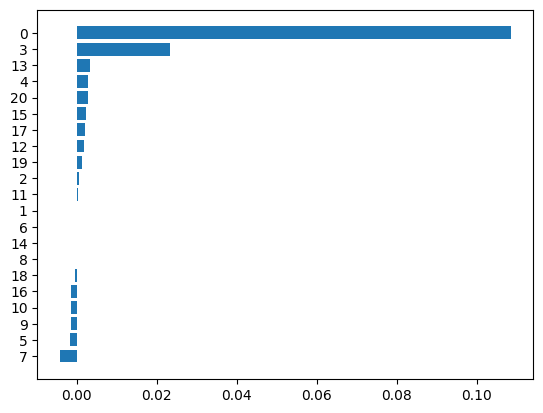

[-4.16666667e-03 -1.56250000e-03 -1.38888889e-03 -1.38888889e-03
 -1.38888889e-03 -5.20833333e-04  0.00000000e+00  1.11022302e-17
  2.22044605e-17  1.73611111e-04  3.47222222e-04  6.94444444e-04
  1.21527778e-03  1.73611111e-03  2.08333333e-03  2.43055556e-03
  2.77777778e-03  2.77777778e-03  3.29861111e-03  2.32638889e-02
  1.08506944e-01]
0.8030127462340672
0.7795138888888888
Intercept: [-4.18533889]
Coefficients: [[ 0.68818132 -0.25165395 -0.38975781 -2.08115981  0.91311945  0.53405942]]
Confusion matrix:
 [[409  68]
 [ 41  58]]
Precision: 0.4603174603174603
Recall: 0.5858585858585859
F1-score: 0.5155555555555555


In [66]:
#DV: rating row[8]
#IDVs: abv - row[6], raters - row[9], text - row[12]-row[30]
import numpy as np
import matplotlib.pyplot as plt
import csv
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score, recall_score
from sklearn.metrics import confusion_matrix
from sklearn.inspection import permutation_importance

#import data from CSVs
data = []
files=["../2_Database/TopBeerData.csv","../2_Database/GoodBeerData.csv","../2_Database/RestBeerData.csv"]
for i in range (0,len(files)):
    with open(files[i],"r",encoding="utf-8") as file:
        reader = csv.reader(file)
        next(reader) # remove header
        for row in reader:
            row.append(i)
            data.append(row)

all_numeric_data = []
numeric_data = []
for row in data[1:]:  # ignore heading
    numeric_data.append([
        float(row[6]),  # 0 abv
        float(row[9]),   # 1 nr of raters
        float(row[12]),  # 2 malt
        float(row[13]),  # 3 hops
        float(row[14]),  # 4 chocolate
        float(row[15]),  # 5 german
        float(row[16]),  # 6 banana
        float(row[17]),  # 7 vanilla
        float(row[18]),  # 8 caramel
        float(row[19]),  # 9 yeast
        float(row[20]),  # 10 fruit
        float(row[21]),  # 11 whiskey
        float(row[22]),  # 12 rhum
        float(row[23]),  # 13 alcohol
        float(row[24]),  # 14 gluten
        float(row[25]),  # 15 barrel
        float(row[26]),  # 16 rye
        float(row[27]),  # 17 barley
        float(row[28]),  # 18 cocoa
        float(row[29]),  # 19 small/lower
        float(row[30]),  # 20 big/upper
        float(row[31]) #id 0-Top, 1-Good, 2-Rest need to stay the last coloumn
    ])
numeric_data = np.array(numeric_data)
all_numeric_data.append(numeric_data)

combined = np.vstack(all_numeric_data)

#IDVs + DV def
#only to use top beers (0) OR good beers (1)
mask = (combined[:, -1] == 1) | (combined[:, -1] == 2) | (combined[:, -1] == 0)
filtered_data = numeric_data[mask]
X = filtered_data[:, :-1]
y = (filtered_data[:, -1] == 0) | (filtered_data[:, -1] == 1) #true if 0 or 1, else otherwise

# train-test split randomly
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

# model
model = LogisticRegression(
    #penalty = "l1",
    #solver = "saga",
    C=1,
    max_iter=5000,
    class_weight="balanced"
)
# train
model.fit(X_train, y_train)

# prediction
treshold = 0.55
#y_prob = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = y_prob > treshold
#print(y_pred)
# accuracy
print(model.score(X_train, y_train))
print(model.score(X_test, y_test))

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)
cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n", cm)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
print("Precision:", precision) #higher is better
print("Recall:", recall)
print("F1-score:", (2*precision*recall)/(precision+recall))

#permutation of features to eliminate features
baseline = model.score(X_test, y_test)
X_test_perm = X_test.copy()
X_test_perm[:, i] = np.random.permutation(X_test_perm[:, i])
score_perm = model.score(X_test_perm, y_test)
importance_i = baseline - score_perm

result = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)
result.importances_mean
result.importances_std
sorted_idx = result.importances_mean.argsort()

plt.barh(
    range(X.shape[1]),
    result.importances_mean[sorted_idx]
)

plt.yticks(range(X.shape[1]), sorted_idx)
plt.show()
print(result.importances_mean[sorted_idx])

top_idx = np.argsort(result.importances_mean)[-6:] #based on the graph only the top features are to be used, others are just confusion
X_train_sel = X_train[:, top_idx]
X_test_sel = X_test[:, top_idx]
model.fit(X_train_sel, y_train)

# prediction
treshold2 = 0.63
y_prob_sel = model.predict_proba(X_test_sel)[:, 1]
y_pred_sel = y_prob_sel > treshold2
# accuracy
print(model.score(X_train_sel, y_train))
print(model.score(X_test_sel, y_test))

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)
cm = confusion_matrix(y_test, y_pred_sel)
print("Confusion matrix:\n", cm)
precision = precision_score(y_test, y_pred_sel)
recall = recall_score(y_test, y_pred_sel)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", (2*precision*recall)/(precision+recall))

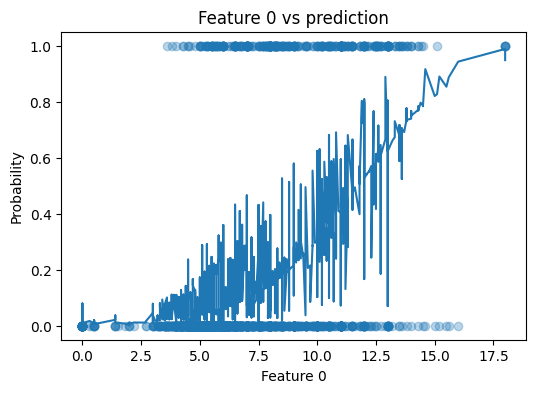

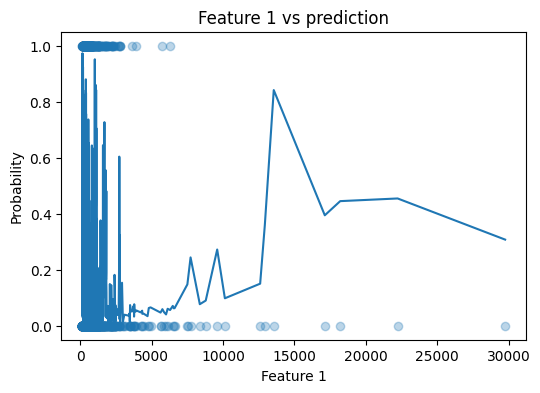

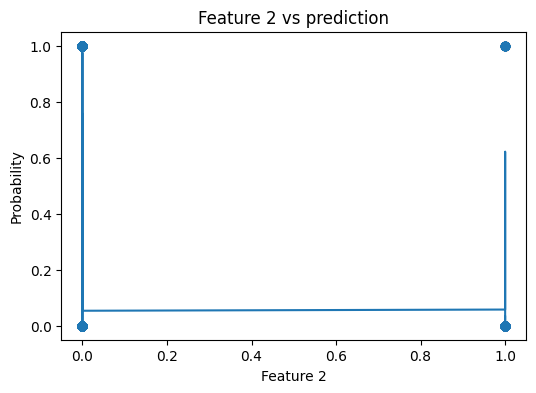

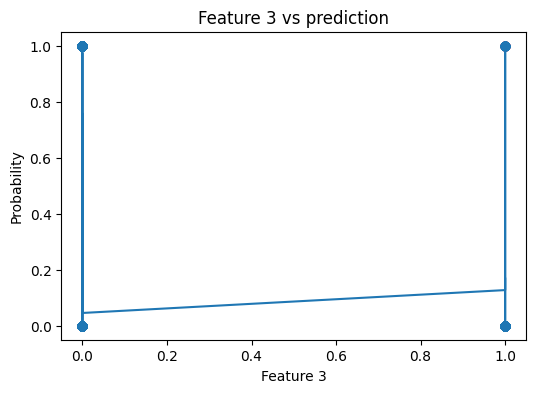

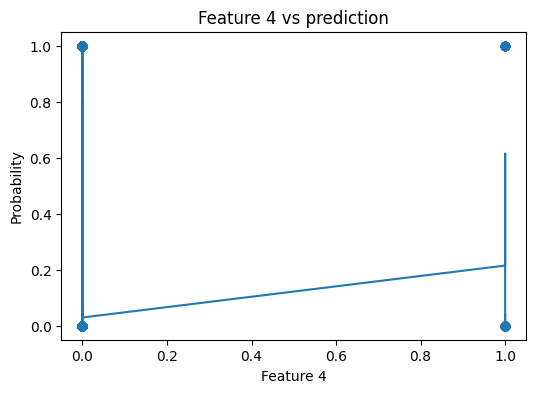

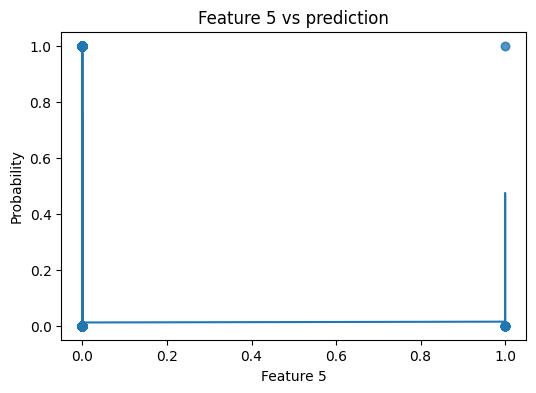

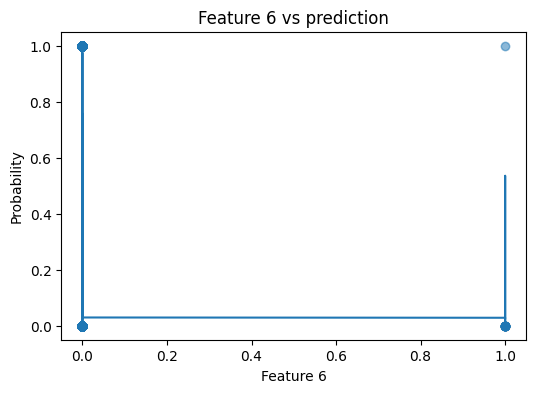

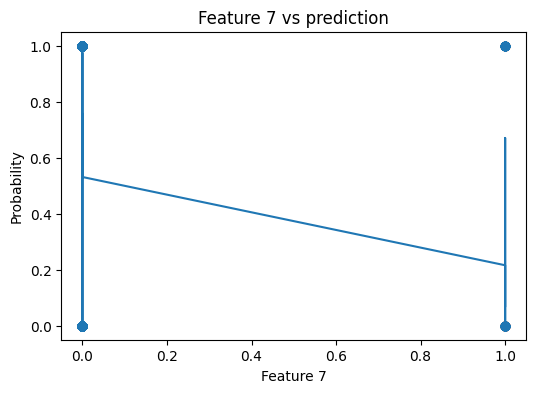

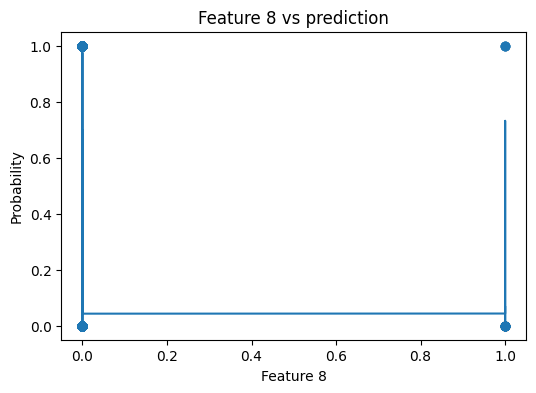

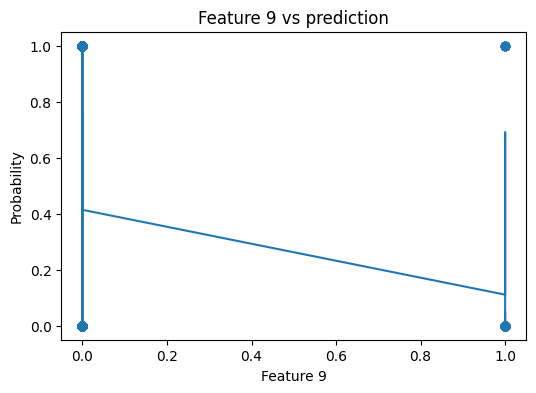

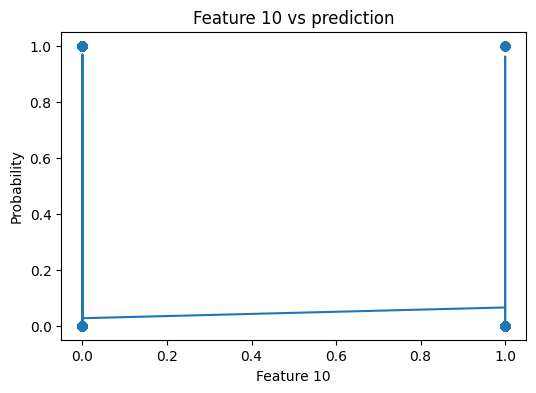

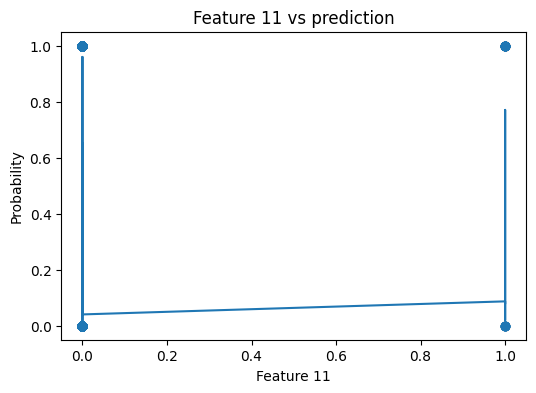

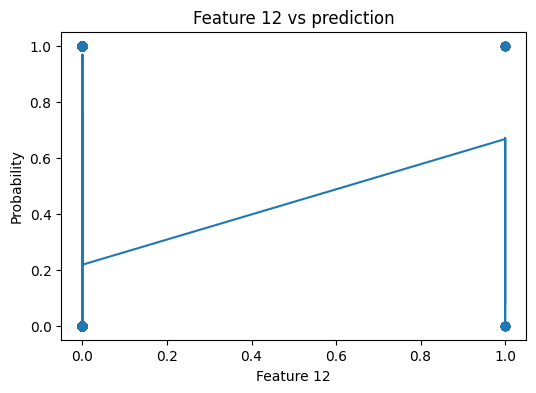

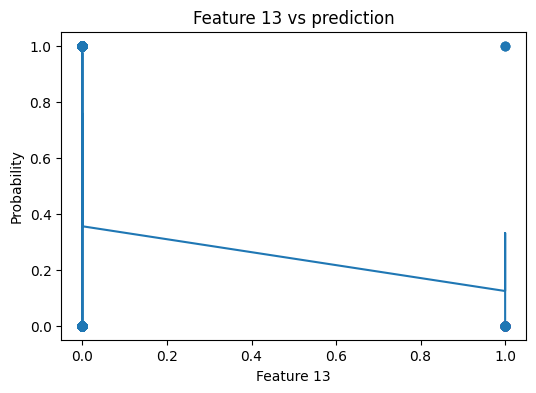

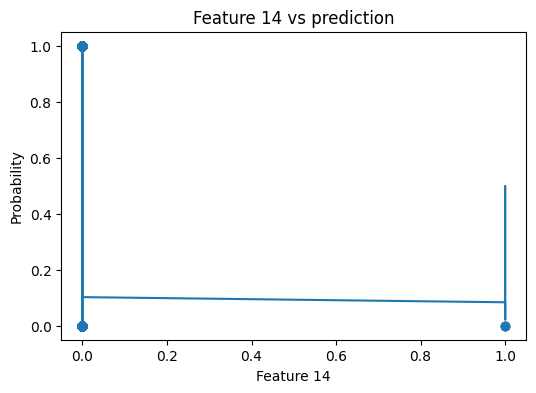

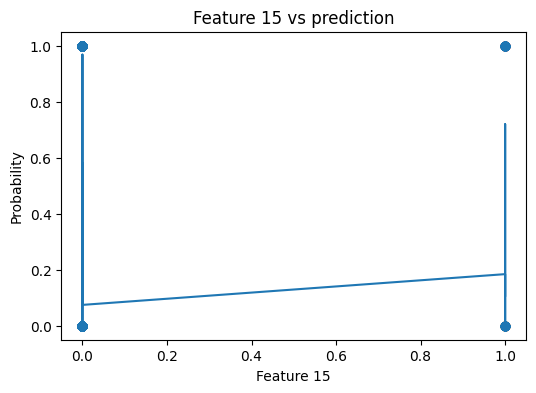

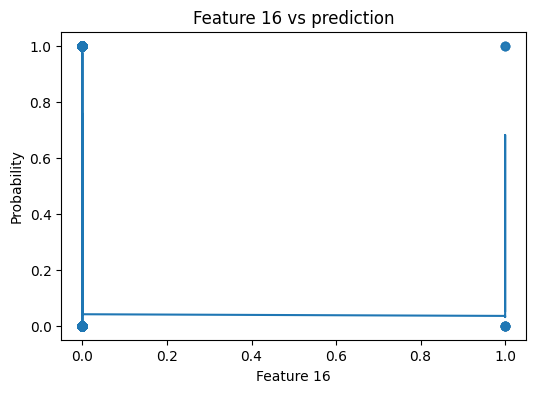

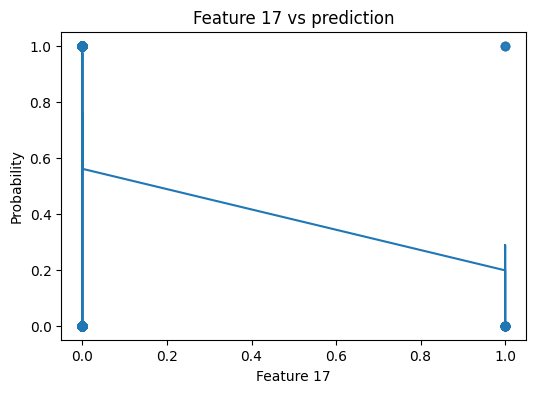

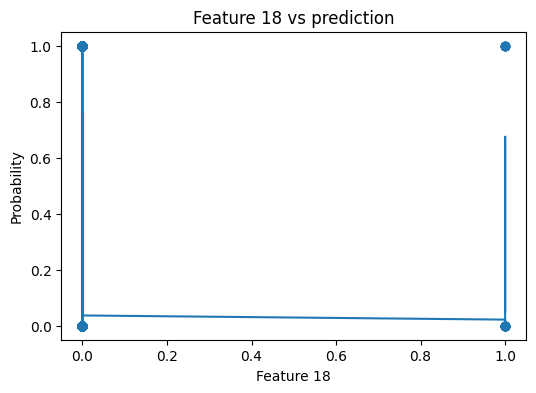

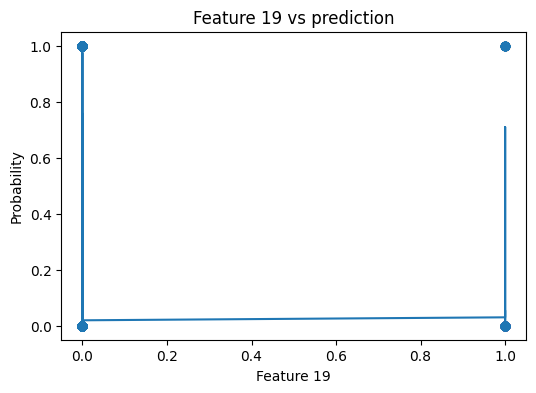

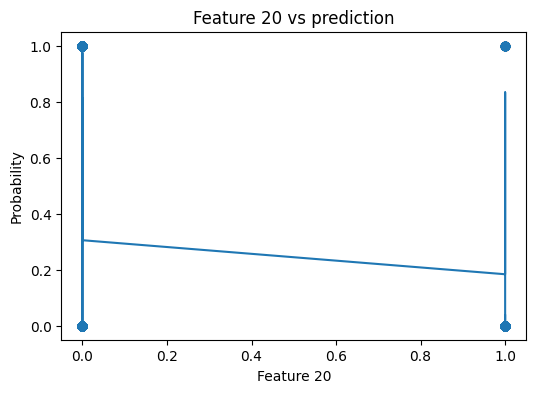

In [67]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression

# modell
model = LogisticRegression(max_iter=1000)
model.fit(X, y)

n_features = X.shape[1]

for i in range(n_features):

    x_feature = X[:, i]

    # scatter
    plt.figure(figsize=(6,4))
    plt.scatter(x_feature, y, alpha=0.3)

    # rendezés a szép görbéhez
    idx = np.argsort(x_feature)

    x_sorted = x_feature[idx]

    # teljes X másolása
    X_temp = X.copy()

    # csak az i-edik feature változik
    X_temp[:, i] = x_sorted

    # valószínűségek
    y_prob = model.predict_proba(X_temp)[:, 1]

    # görbe
    plt.plot(x_sorted, y_prob)

    plt.xlabel(f"Feature {i}")
    plt.ylabel("Probability")
    plt.title(f"Feature {i} vs prediction")

    plt.show()

Accuracy: 0.8465991316931982
Precision: 0.5423728813559322
Recall: 0.5517241379310345

Confusion matrix:
[[521  54]
 [ 52  64]]
F1-score: 0.547008547008547


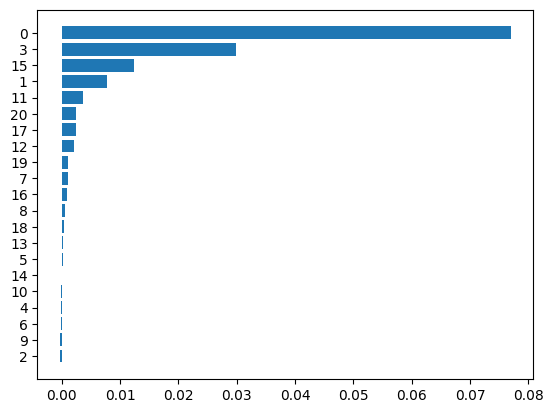

[-0.00028944 -0.00028944 -0.00014472 -0.00014472 -0.00014472  0.
  0.00014472  0.00014472  0.00043415  0.00057887  0.00086831  0.00101302
  0.00101302  0.00217077  0.0024602   0.0024602   0.00361795  0.00781476
  0.01244573  0.02995658  0.07698987]
0.9987585350713842
0.8639652677279306
Accuracy: 0.8523878437047757
Precision: 0.5636363636363636
Recall: 0.5344827586206896

Confusion matrix:
[[527  48]
 [ 54  62]]
F1-score: 0.5486725663716814


In [68]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

# -------------------------
# FILTER
# -------------------------

mask = (
    (combined[:, -1] == 0) |
    (combined[:, -1] == 1) |
    (combined[:, -1] == 2)
)

filtered_data = combined[mask]

X = filtered_data[:, :-1]
y = (filtered_data[:, -1] == 1) | (filtered_data[:, -1] == 0) 

# -------------------------
# SPLIT
# -------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# -------------------------
# MODEL
# -------------------------

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
y_prob = model.predict_proba(X_test)[:, 1]
threshold = 0.37
y_pred = y_prob > threshold

# -------------------------
# METRICS
# -------------------------
print("Accuracy:",      accuracy_score(y_test, y_pred))
print("Precision:",      precision_score(y_test, y_pred))
print("Recall:",      recall_score(y_test, y_pred))
print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))
#print("\nClassification report:")
#print(classification_report(y_test, y_pred))
print("F1-score:", (2*precision_score(y_test, y_pred)*recall_score(y_test, y_pred))/(precision_score(y_test, y_pred)+recall_score(y_test, y_pred)))

#permutation of features to eliminate features
baseline = model.score(X_test, y_test)
X_test_perm = X_test.copy()
X_test_perm[:, i] = np.random.permutation(X_test_perm[:, i])
score_perm = model.score(X_test_perm, y_test)
importance_i = baseline - score_perm

result = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)
result.importances_mean
result.importances_std
sorted_idx = result.importances_mean.argsort()

plt.barh(
    range(X.shape[1]),
    result.importances_mean[sorted_idx]
)

plt.yticks(range(X.shape[1]), sorted_idx)
plt.show()
print(result.importances_mean[sorted_idx])
top_idx = np.argsort(result.importances_mean)[-18:] #based on the graph only the top features are to be used, others are just confusion
X_train_sel = X_train[:, top_idx]
X_test_sel = X_test[:, top_idx]
model.fit(X_train_sel, y_train)

# prediction
treshold2 = 0.4
y_prob_sel = model.predict_proba(X_test_sel)[:, 1]
y_pred_sel = y_prob_sel > treshold2
# accuracy
print(model.score(X_train_sel, y_train))
print(model.score(X_test_sel, y_test))

print("Accuracy:",      accuracy_score(y_test, y_pred_sel))
print("Precision:",      precision_score(y_test, y_pred_sel))
print("Recall:",      recall_score(y_test, y_pred_sel))
print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred_sel))
#print("\nClassification report:")
#print(classification_report(y_test, y_pred))
print("F1-score:", (2*precision_score(y_test, y_pred_sel)*recall_score(y_test, y_pred_sel))/(precision_score(y_test, y_pred_sel)+recall_score(y_test, y_pred_sel)))